In [1]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score , confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Uploading the dataset
data = pd.read_csv('heart.csv')

In [ ]:
# Viewing the dataset
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


<Axes: >

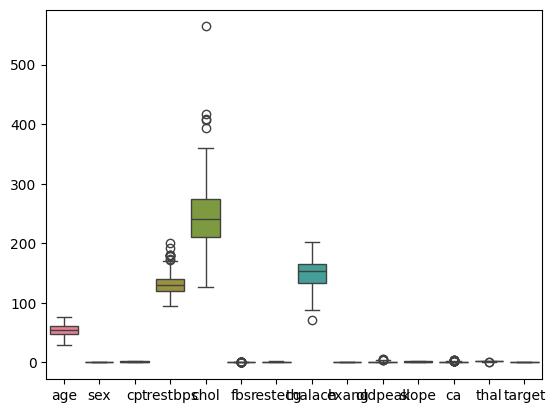

In [4]:
# Checking the dataset for noise
sns.boxplot(data)

In [5]:
# Defining a function to clean noises
def cleaning(series : pd.Series , factor: float = 1.5):
    q1 , q3 = series.quantile([0.25 , 0.75])
    iqr =  q3 - q1
    low = q1 - iqr * factor
    high = q3 + iqr * factor
    return low , high

In [6]:
# Enforcing the function on noisy columns
for i in ['trestbps' , 'chol' , 'thalach']:
    if i in data.columns:
        f = data[i].astype(float)
        low , high = cleaning(f , factor = 1.5)
        output = (f < low ) | (f > high)
        print(output.sum())
        data.loc[f < low , i] = low
        data.loc[f > high , i] = high

9
5
1


C:\Users\lenanika\AppData\Local\Temp\ipykernel_22156\2954687718.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '115.75' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[f < low , i] = low
C:\Users\lenanika\AppData\Local\Temp\ipykernel_22156\2954687718.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '84.75' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[f < low , i] = low


<Axes: >

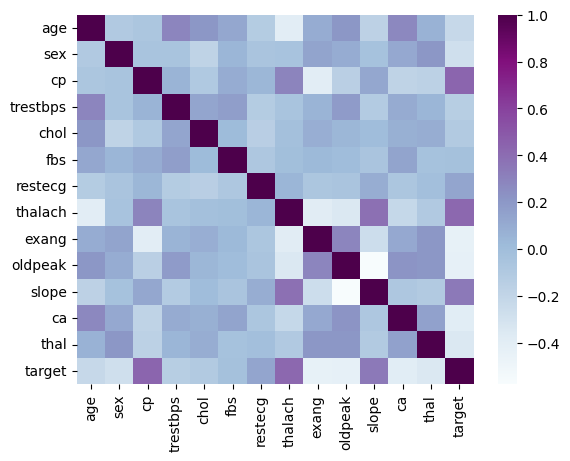

In [7]:
# Viewing the relationship between columns
sns.heatmap(data.corr() , annot = False , cmap = 'BuPu')

In [8]:
# Creating X and y
X = data.drop('target' , axis = 1)
y = data['target']

In [9]:
# Splitting data into train and test sets
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2)

In [10]:
# Standardizing the X data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Training model
rf = RandomForestClassifier(n_estimators = 30 , min_samples_leaf = 2)
rf.fit(X_train_scaled , y_train)

,n_estimators,30
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
# Predicting
rf_pred = rf.predict(X_test_scaled)

In [13]:
# Model accuracy
accuracy_score(y_test , rf_pred)

0.819672131147541

<Axes: >

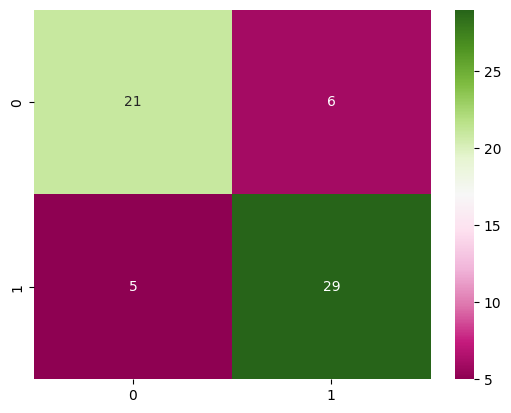

In [14]:
# Viewing the model's errors
sns.heatmap(confusion_matrix(y_test , rf_pred) , annot = True , cmap = 'PiYG')

In [15]:
# Using feature importance to determine which columns were more relevant for the model
features = ['age' , 'sex' , 'cp' , 'trestbps' , 'chol' ,'fbs' , 'restecg' , 'thalach' , 'exang' , 'oldpeak' , 'slope' , 'ca' , 'thal']
pd.Series(rf.feature_importances_ , index = features).sort_values(ascending = False)

cp          0.172033
thalach     0.139960
oldpeak     0.125851
ca          0.110741
thal        0.094228
age         0.088139
slope       0.062662
chol        0.051284
trestbps    0.043164
sex         0.039611
exang       0.038760
restecg     0.025586
fbs         0.007980
dtype: float64